# Tiền Xử Lý Dữ Liệu Thời Tiết Việt Nam

Notebook này thực hiện:
1. **Đọc dữ liệu** từ `datasetall.csv`
2. **Kiểm tra chất lượng** — trùng lặp, giá trị thiếu, ngoại lai, giá trị không hợp lệ
3. **Đánh giá & Quyết định xử lý** — tổng hợp các quyết định tiền xử lý sau khi kiểm tra
4. **Tiền xử lý** — làm sạch và chuẩn hoá theo các quyết định
5. **Lưu kết quả** sau khi xử lý

## 1. Import thư viện & Đọc dữ liệu

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# --- Cấu hình hiển thị ---
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_theme(style='whitegrid', palette='muted')

print('Import thư viện thành công')

Import thư viện thành công


In [17]:
# --- Đọc dữ liệu ---
DATA_PATH = '../backend/data/datasetall.csv'
df = pd.read_csv(DATA_PATH, parse_dates=['date'])

print('Đọc dữ liệu thành công!')
print(f'   Kích thước: {df.shape[0]:,} dòng x {df.shape[1]} cột')
print(f'   Khoảng thời gian: {df["date"].min().date()} -> {df["date"].max().date()}')

Đọc dữ liệu thành công!
   Kích thước: 58,887 dòng x 14 cột
   Khoảng thời gian: 2024-01-01 -> 2026-07-23


In [18]:
# --- Xem nhanh dữ liệu ---
df.head()

,date,city_id,province,country,latitude,longitude,temperature_max,temperature_min,temperature_mean,rain_sum,humidity_mean,wind_speed_max,aqi,cloud_cover_mean
0,2024-01-01,707,Bắc Ninh,Viet Nam,21.19,106.08,26.30,17.70,21.80,0.00,80,15.60,75,52
1,2024-01-01,590,Đà Nẵng,Viet Nam,16.05,108.21,25.30,22.50,23.70,3.90,86,15.80,36,91
2,2024-01-01,365,Cà Mau,Viet Nam,9.18,105.15,31.10,23.10,26.80,1.50,78,19.50,26,97
3,2024-01-01,278,Đồng Nai,Viet Nam,10.96,106.84,32.10,23.60,27.40,0.00,76,11.30,68,100
4,2024-01-01,347,Bình Phước,Viet Nam,11.75,106.88,32.60,21.70,26.80,0.00,69,10.70,32,88


In [19]:
# --- Thông tin kiểu dữ liệu ---
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 58887 entries, 0 to 58886
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              58887 non-null  datetime64[us]
 1   city_id           58887 non-null  int64         
 2   province          58887 non-null  str           
 3   country           58887 non-null  str           
 4   latitude          58887 non-null  float64       
 5   longitude         58887 non-null  float64       
 6   temperature_max   58887 non-null  float64       
 7   temperature_min   58887 non-null  float64       
 8   temperature_mean  58887 non-null  float64       
 9   rain_sum          58887 non-null  float64       
 10  humidity_mean     58887 non-null  int64         
 11  wind_speed_max    58887 non-null  float64       
 12  aqi               58887 non-null  int64         
 13  cloud_cover_mean  58887 non-null  int64         
dtypes: datetime64[us](1), float64(7),

In [20]:
# --- Thống kê mô tả ---
df.describe()

,date,city_id,latitude,longitude,temperature_max,temperature_min,temperature_mean,rain_sum,humidity_mean,wind_speed_max,aqi,cloud_cover_mean
count,58887,58887.00,58887.00,58887.00,58887.00,58887.00,58887.00,58887.00,58887.00,58887.00,58887.00,58887.00
mean,2025-04-11 20:34:26.574965,496.30,15.83,106.53,29.51,22.35,25.46,5.69,79.54,15.68,50.42,73.54
min,2024-01-01 00:00:00,108.00,9.18,103.02,7.00,2.60,5.00,0.00,30.00,2.30,10.00,0.00
25%,2024-08-21 00:00:00,237.00,10.67,105.60,27.30,20.50,23.60,0.00,74.00,11.50,32.00,56.00
50%,2025-04-12 00:00:00,495.00,16.05,106.10,30.30,23.70,26.50,1.10,81.00,14.80,46.00,83.00
75%,2025-12-02 00:00:00,734.00,21.03,107.14,32.40,25.20,28.10,7.10,87.00,18.70,66.00,97.00
max,2026-07-23 00:00:00,981.00,22.82,115.83,42.90,33.00,36.30,248.70,100.00,101.80,176.00,100.00
std,NaN,273.11,4.94,1.95,4.42,4.29,4.04,10.89,9.27,6.27,22.33,26.74


---
## 2. Kiểm Tra Chất Lượng Dữ Liệu

### 2.1 Kiểm Tra Giá Trị Thiếu (Missing Values)

In [21]:
# --- Tỉ lệ thiếu từng cột ---
missing = pd.DataFrame({
    'Số lượng thiếu': df.isnull().sum(),
    'Tỉ lệ thiếu (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing['Số lượng thiếu'] > 0].sort_values('Tỉ lệ thiếu (%)', ascending=False)

if missing.empty:
    print('Không có giá trị thiếu!')
else:
    print(f'Phát hiện giá trị thiếu ở {len(missing)} cột:')
    display(missing)

    # Biểu đồ tỉ lệ thiếu
    fig, ax = plt.subplots(figsize=(8, max(3, len(missing)*0.5)))
    missing['Tỉ lệ thiếu (%)'].plot(kind='barh', ax=ax, color='#e74c3c', edgecolor='white')
    ax.set_xlabel('Tỉ lệ thiếu (%)')
    ax.set_title('Tỉ lệ giá trị thiếu theo cột')
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
    plt.tight_layout()
    plt.show()

Không có giá trị thiếu!


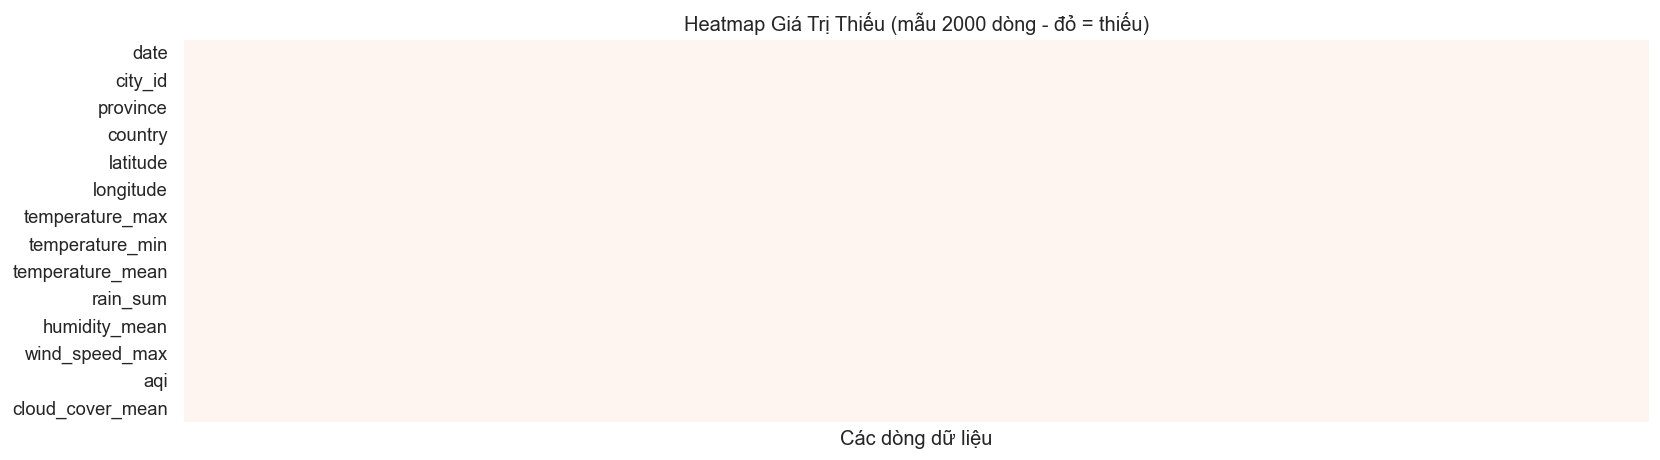

In [22]:
# --- Heatmap tổng quan giá trị thiếu ---
fig, ax = plt.subplots(figsize=(14, 4))
missing_bool = df.isnull()
# Lấy mẫu tối đa 2000 dòng để hiển thị nhanh
sample_idx = missing_bool.sample(min(2000, len(df)), random_state=42).index.sort_values()
sns.heatmap(missing_bool.loc[sample_idx].T, cbar=False, cmap='Reds',
            yticklabels=True, xticklabels=False, ax=ax)
ax.set_title('Heatmap Giá Trị Thiếu (mẫu 2000 dòng - đỏ = thiếu)')
ax.set_xlabel('Các dòng dữ liệu')
plt.tight_layout()
plt.show()

### 2.2 Kiểm Tra Trùng Lặp (Duplicates)

In [23]:
# --- Trùng toàn bộ dòng ---
n_dup_full = df.duplicated().sum()
print(f'Dòng trùng hoàn toàn  : {n_dup_full:,}')

# --- Trùng theo khóa tự nhiên (date, city_id) ---
key_cols = ['date', 'city_id']
n_dup_key = df.duplicated(subset=key_cols).sum()
print(f'Trùng theo (date, city_id): {n_dup_key:,}')

if n_dup_full > 0:
    print('\n--- Ví dụ các dòng trùng ---')
    display(df[df.duplicated(keep=False)].head(10))

if n_dup_key > 0 and n_dup_key != n_dup_full:
    print('\n--- Ví dụ trùng khóa (date, city_id) ---')
    display(df[df.duplicated(subset=key_cols, keep=False)].head(10))

Dòng trùng hoàn toàn  : 52
Trùng theo (date, city_id): 52

--- Ví dụ các dòng trùng ---


,date,city_id,province,country,latitude,longitude,temperature_max,temperature_min,temperature_mean,rain_sum,humidity_mean,wind_speed_max,aqi,cloud_cover_mean
946,2024-01-16,521,TP. Hồ Chí Minh,Viet Nam,10.82,106.63,33.20,23.20,27.90,0.00,65,14.80,65,75
947,2024-01-16,326,Thừa Thiên Huế,Viet Nam,16.46,107.58,25.90,18.10,22.00,0.60,81,20.20,34,40
954,2024-01-16,920,Vĩnh Long,Viet Nam,10.25,105.97,31.80,23.30,26.40,3.70,78,14.80,63,82
988,2024-01-16,495,Nghệ An,Viet Nam,18.67,105.67,25.00,19.50,21.60,2.30,85,18.90,38,35
989,2024-01-16,587,Trà Vinh,Viet Nam,9.93,106.33,31.10,24.20,26.90,0.00,72,13.70,32,86
991,2024-01-16,981,Quảng Bình,Viet Nam,17.47,106.60,24.30,19.60,22.20,3.80,82,22.20,37,35
995,2024-01-16,767,Kiên Giang,Viet Nam,10.01,105.08,31.80,22.80,27.10,0.30,72,13.20,55,91
999,2024-01-16,146,Tiền Giang,Viet Nam,10.36,106.36,33.10,23.10,26.90,0.00,75,11.80,45,81
1000,2024-01-16,326,Thừa Thiên Huế,Viet Nam,16.46,107.58,25.90,18.10,22.00,0.60,81,20.20,34,40
1001,2024-01-16,981,Quảng Bình,Viet Nam,17.47,106.60,24.30,19.60,22.20,3.80,82,22.20,37,35


### 2.3 Kiểm Tra Giá Trị Không Hợp Lệ (Invalid Values)

In [24]:
# --- Định nghĩa miền hợp lệ cho từng cột số ---
VALID_RANGES = {
    'temperature_max':  (-10, 50),   # °C
    'temperature_min':  (-10, 50),   # °C
    'temperature_mean': (-10, 50),   # °C
    'rain_sum':         (0,  1000),  # mm
    'humidity_mean':    (0,  100),   # %
    'wind_speed_max':   (0,  200),   # km/h
    'aqi':              (0,  500),   # AQI
    'cloud_cover_mean': (0,  100),   # %
    'latitude':         (-90,  90),
    'longitude':        (-180, 180),
}

invalid_report = []
for col, (lo, hi) in VALID_RANGES.items():
    if col in df.columns:
        mask = df[col].notna() & ((df[col] < lo) | (df[col] > hi))
        cnt = mask.sum()
        invalid_report.append({'Cột': col, 'Min hợp lệ': lo, 'Max hợp lệ': hi,
                                'Số lỗi': cnt, 'Tỉ lệ (%)': round(cnt/len(df)*100, 3)})

invalid_df = pd.DataFrame(invalid_report)
invalid_found = invalid_df[invalid_df['Số lỗi'] > 0]

if invalid_found.empty:
    print('Tất cả giá trị số đều nằm trong miền hợp lệ!')
else:
    print(f'Phát hiện giá trị ngoài miền ở {len(invalid_found)} cột:')
    display(invalid_found)
    # Hiển thị ví dụ từng cột lỗi
    for col, (lo, hi) in VALID_RANGES.items():
        if col in df.columns:
            mask = df[col].notna() & ((df[col] < lo) | (df[col] > hi))
            if mask.sum() > 0:
                print(f'\n--- Mẫu dòng lỗi cột [{col}] ---')
                display(df[mask][['date','province','city_id', col]].head(5))

Tất cả giá trị số đều nằm trong miền hợp lệ!


In [25]:
# --- Kiểm tra logic: temperature_min <= temperature_mean <= temperature_max ---
temp_cols = ['temperature_min', 'temperature_mean', 'temperature_max']
if all(c in df.columns for c in temp_cols):
    mask_logic1 = df['temperature_min'] > df['temperature_max']
    mask_logic2 = (df['temperature_mean'] < df['temperature_min']) | (df['temperature_mean'] > df['temperature_max'])
    print(f'Dòng có temp_min > temp_max           : {mask_logic1.sum():,}')
    print(f'Dòng có temp_mean ngoài [min, max]    : {mask_logic2.sum():,}')
    if mask_logic1.sum() > 0:
        display(df[mask_logic1][['date','province'] + temp_cols].head())
    if mask_logic2.sum() > 0:
        display(df[mask_logic2][['date','province'] + temp_cols].head())

Dòng có temp_min > temp_max           : 0
Dòng có temp_mean ngoài [min, max]    : 0


In [26]:
# --- Kiểm tra cột dạng chuỗi ---
str_cols = ['province', 'country']
for col in str_cols:
    if col not in df.columns:
        continue
    n_empty = (df[col].str.strip() == '').sum()
    print(f'[{col}] - giá trị rỗng/khoảng trắng: {n_empty}')
    print(f'   Số giá trị duy nhất: {df[col].nunique()}')
    if col == 'province':
        print(f'   Danh sách: {sorted(df[col].unique())[:20]}')

[province] - giá trị rỗng/khoảng trắng: 0
   Số giá trị duy nhất: 63
   Danh sách: ['An Giang', 'Bà Rịa – Vũng Tàu', 'Bình Dương', 'Bình Phước', 'Bình Thuận', 'Bình Định', 'Bạc Liêu', 'Bắc Giang', 'Bắc Kạn', 'Bắc Ninh', 'Bến Tre', 'Cao Bằng', 'Cà Mau', 'Cần Thơ', 'Gia Lai', 'Hoàng Sa', 'Hà Giang', 'Hà Nam', 'Hà Nội', 'Hà Tĩnh']
[country] - giá trị rỗng/khoảng trắng: 0
   Số giá trị duy nhất: 1


### 2.4 Phát Hiện Ngoại Lai (Outliers) — Phương pháp IQR & Z-Score

In [27]:
# --- IQR Outlier Detection ---
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
skip_cols = ['city_id', 'latitude', 'longitude']
analysis_cols = [c for c in numeric_cols if c not in skip_cols]

outlier_summary = []
for col in analysis_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    mask = (df[col] < lo) | (df[col] > hi)
    cnt = mask.sum()
    outlier_summary.append({
        'Cột': col, 'Q1': round(Q1,2), 'Q3': round(Q3,2), 'IQR': round(IQR,2),
        'Ngưỡng dưới': round(lo,2), 'Ngưỡng trên': round(hi,2),
        'Số ngoại lai': cnt, 'Tỉ lệ (%)': round(cnt/len(df)*100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values('Số ngoại lai', ascending=False)
print('Kết quả phát hiện ngoại lai (IQR x 1.5):')
display(outlier_df)

Kết quả phát hiện ngoại lai (IQR x 1.5):


,Cột,Q1,Q3,IQR,Ngưỡng dưới,Ngưỡng trên,Số ngoại lai,Tỉ lệ (%)
3,rain_sum,0.00,7.10,7.10,-10.65,17.75,5530,9.39
1,temperature_min,20.50,25.20,4.70,13.45,32.25,3337,5.67
2,temperature_mean,23.60,28.10,4.50,16.85,34.85,2700,4.59
0,temperature_max,27.30,32.40,5.10,19.65,40.05,1986,3.37
5,wind_speed_max,11.50,18.70,7.20,0.70,29.50,1688,2.87
4,humidity_mean,74.00,87.00,13.00,54.50,106.50,692,1.18
6,aqi,32.00,66.00,34.00,-19.00,117.00,317,0.54
7,cloud_cover_mean,56.00,97.00,41.00,-5.50,158.50,0,0.00


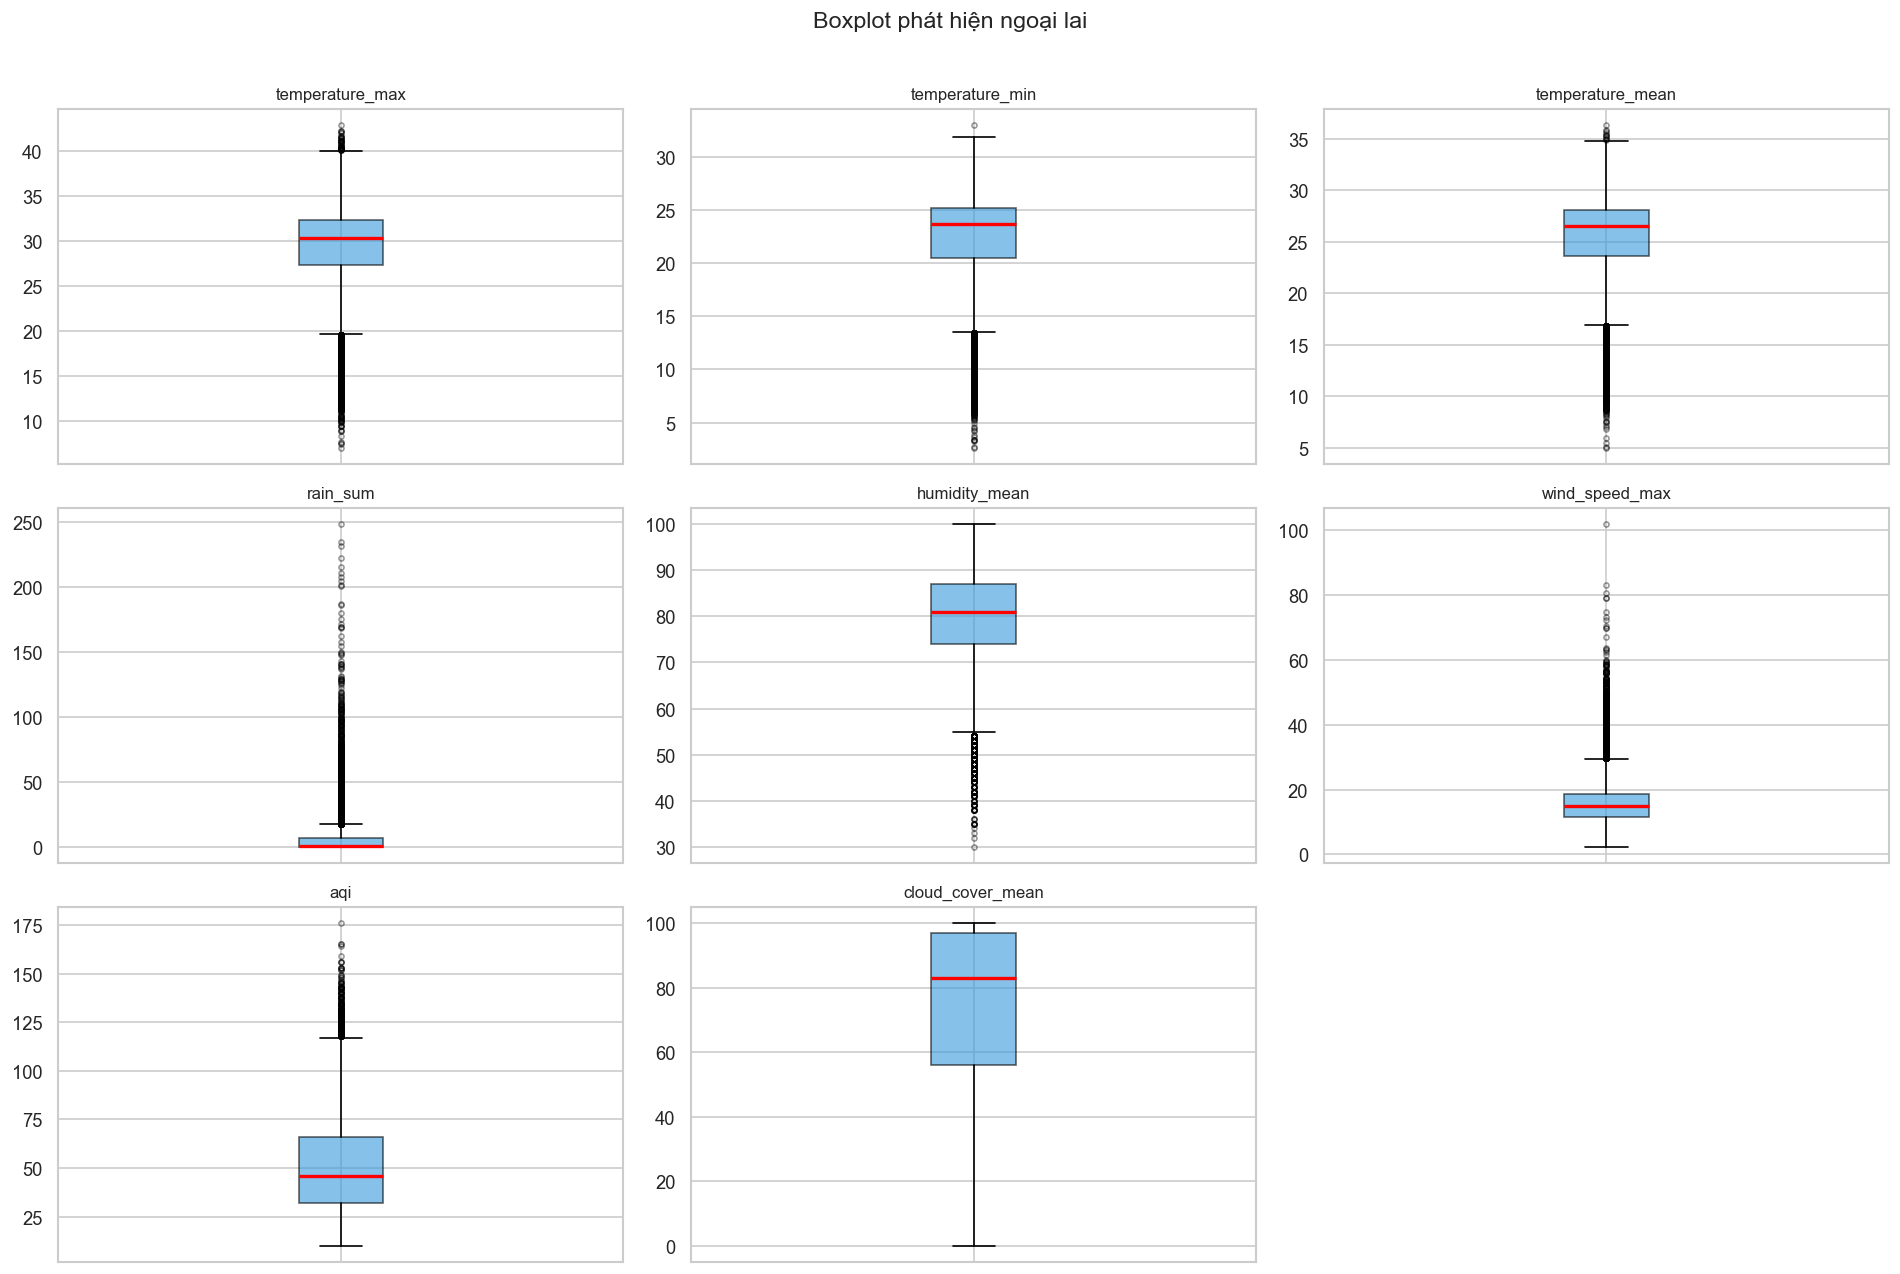

In [28]:
# --- Boxplot trực quan ngoại lai ---
n_cols = 3
n_rows = int(np.ceil(len(analysis_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(analysis_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#3498db', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', color='#e74c3c', alpha=0.4, markersize=3))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xticklabels([])

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Boxplot phát hiện ngoại lai', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [29]:
# --- Z-Score Outlier (|z| > 3) ---
from scipy import stats

zscore_summary = []
for col in analysis_cols:
    z = np.abs(stats.zscore(df[col].dropna()))
    cnt = (z > 3).sum()
    zscore_summary.append({'Cột': col, 'Số ngoại lai |z|>3': cnt,
                            'Tỉ lệ (%)': round(cnt/len(df)*100, 2)})

zscore_df = pd.DataFrame(zscore_summary).sort_values('Số ngoại lai |z|>3', ascending=False)
print('Ngoại lai theo Z-Score (|z| > 3):')
display(zscore_df)

Ngoại lai theo Z-Score (|z| > 3):


,Cột,Số ngoại lai |z|>3,Tỉ lệ (%)
3,rain_sum,977,1.66
5,wind_speed_max,805,1.37
0,temperature_max,594,1.01
1,temperature_min,572,0.97
2,temperature_mean,521,0.88
4,humidity_mean,379,0.64
6,aqi,317,0.54
7,cloud_cover_mean,0,0.00


---
## 3. Các Quyết Định Tiền Xử Lý Dữ Liệu

Sau khi kiểm tra tổng thể chất lượng dữ liệu ở Mục 2, các quyết định xử lý dữ liệu được đưa ra như sau:

### 3.1 Quyết Định Về Trùng Lặp (Duplicates)
- **Hành động**: Loại bỏ các dòng trùng lặp hoàn toàn (`drop_duplicates()`) và trùng lặp theo cặp khóa `(date, city_id)`.
- **Lý do**: Mỗi thành phố/tỉnh trong một ngày chỉ được phép có duy nhất một bản ghi dữ liệu thời tiết để tránh làm sai lệch các chỉ số thống kê.

### 3.2 Quyết Định Về Giá Trị Không Hợp Lệ (Invalid Values)
- **Hành động**: Chuyển các giá trị nằm ngoài miền lý thuyết vật lý (ví dụ: nhiệt độ < -10°C hoặc > 50°C, độ ẩm < 0% hoặc > 100%) thành giá trị thiếu (`NaN`).
- **Hành động logic**: Nếu phát hiện trường hợp `temperature_min > temperature_max`, thực hiện hoán đổi vị trí hai giá trị này.

### 3.3 Quyết Định Về Giá Trị Thiếu (Missing Values)
- **Đối với cột `rain_sum`**: Điền giá trị `0` vì trong dữ liệu thời tiết, việc không ghi nhận lượng mưa đồng nghĩa với ngày không có mưa.
- **Đối với các cột số khác**: 
  - Nếu tỉ lệ thiếu **≤ 30%**: Điền bằng giá trị trung vị (`median`) được tính theo từng tỉnh (`province`). Lý do: Thời tiết của các ngày trong cùng một tỉnh có tính tương đồng cao.
  - Nếu tỉ lệ thiếu **> 30%** hoặc tỉnh không có đủ dữ liệu: Điền bằng giá trị trung vị toàn cục (`global median`).

### 3.4 Quyết Định Về Giá Trị Ngoại Lai (Outliers) — GIỮ NGUYÊN
- **Hành động**: **KHÔNG loại bỏ và KHÔNG cắt gọt (clip/winsorize) các giá trị ngoại lai**.
- **Lý do chi tiết**:
  1. **Bản chất dữ liệu thời tiết**: Dữ liệu thời tiết tự nhiên vốn mang tính biến động cao và thường xuyên xuất hiện các hiện tượng cực đoan (nắng nóng đỉnh điểm, đợt không khí lạnh mạnh, mưa lớn do bão, gió giật mạnh, ô nhiễm không khí tăng đột biến). Các giá trị được coi là "ngoại lai" trên góc độ thống kê (như IQR hay Z-score) thực chất là phản ánh các sự kiện thời tiết thực tế.
  2. **Tỉ lệ ngoại lai không quá lớn**: Qua kiểm tra ở Mục 2.4, tỉ lệ các điểm ngoại lai ở tất cả các biến số đều ở mức thấp (thường dưới 1 - 3%), không gây lệch quá nghiêm trọng đến phân bố tổng thể.
  3. **Bảo tồn giá trị phân tích**: Việc giữ nguyên ngoại lai giúp mô hình và các biểu đồ trực quan hóa phản ánh chính xác các đợt thời tiết cực đoan — một yếu tố rất quan trọng trong phân tích và dự báo thời tiết.



---
## 4. Thực Hiện Tiền Xử Lý Dữ Liệu

In [30]:
# Tạo bản sao để xử lý
df_clean = df.copy()
print(f'Bắt đầu tiền xử lý: {df_clean.shape[0]:,} dòng x {df_clean.shape[1]} cột')

Bắt đầu tiền xử lý: 58,887 dòng x 14 cột


### 4.1 Xóa Dòng Trùng Lặp

In [31]:
before = len(df_clean)

# Bước 1: Xóa dòng trùng hoàn toàn
df_clean.drop_duplicates(inplace=True)
after_full_dup = len(df_clean)

# Bước 2: Xóa trùng theo khóa (date, city_id) — giữ dòng đầu
df_clean.drop_duplicates(subset=['date', 'city_id'], keep='first', inplace=True)
after_key_dup = len(df_clean)

print(f'Xóa dòng trùng hoàn toàn : {before - after_full_dup:,} dòng')
print(f'Xóa trùng khóa (date, city_id): {after_full_dup - after_key_dup:,} dòng')
print(f'Còn lại: {after_key_dup:,} dòng')

Xóa dòng trùng hoàn toàn : 52 dòng
Xóa trùng khóa (date, city_id): 0 dòng
Còn lại: 58,835 dòng


### 4.2 Xử Lý Giá Trị Không Hợp Lệ

In [32]:
invalid_total = 0

for col, (lo, hi) in VALID_RANGES.items():
    if col not in df_clean.columns:
        continue
    # Chuyển giá trị ngoài miền -> NaN
    mask = (df_clean[col] < lo) | (df_clean[col] > hi)
    cnt = mask.sum()
    if cnt > 0:
        df_clean.loc[mask, col] = np.nan
        invalid_total += cnt
        print(f'  [{col}]: {cnt:,} giá trị ngoài [{lo}, {hi}] -> NaN')

# Sửa logic nhiệt độ: nếu temp_min > temp_max -> hoán đổi
temp_cols = ['temperature_min', 'temperature_mean', 'temperature_max']
if all(c in df_clean.columns for c in temp_cols):
    mask_swap = df_clean['temperature_min'] > df_clean['temperature_max']
    n_swap = mask_swap.sum()
    if n_swap > 0:
        df_clean.loc[mask_swap, ['temperature_min', 'temperature_max']] = \
            df_clean.loc[mask_swap, ['temperature_max', 'temperature_min']].values
        print(f'  Hoán đổi temp_min <-> temp_max: {n_swap:,} dòng')

print(f'\nTổng cộng {invalid_total:,} giá trị không hợp lệ đã được chuyển sang NaN')


Tổng cộng 0 giá trị không hợp lệ đã được chuyển sang NaN


### 4.3 Xử Lý Giá Trị Thiếu

In [33]:
fill_log = []
numeric_fill_cols = [c for c in analysis_cols if c in df_clean.columns]

for col in numeric_fill_cols:
    n_missing = df_clean[col].isnull().sum()
    if n_missing == 0:
        continue
    ratio = n_missing / len(df_clean)

    if col == 'rain_sum':
        df_clean[col].fillna(0, inplace=True)
        fill_log.append({'Cột': col, 'Số thiếu': n_missing, 'Chiến lược': 'Điền 0 (không mưa)'})
    elif ratio <= 0.30:
        # Điền median theo tỉnh
        df_clean[col] = df_clean.groupby('province')[col].transform(
            lambda x: x.fillna(x.median())
        )
        # Nếu vẫn còn thiếu (tỉnh chỉ có NaN) -> dùng median toàn cục
        global_median = df_clean[col].median()
        df_clean[col].fillna(global_median, inplace=True)
        fill_log.append({'Cột': col, 'Số thiếu': n_missing,
                         'Chiến lược': f'Median theo tỉnh (fallback global={global_median:.2f})'})
    else:
        global_median = df_clean[col].median()
        df_clean[col].fillna(global_median, inplace=True)
        fill_log.append({'Cột': col, 'Số thiếu': n_missing,
                         'Chiến lược': f'Median toàn cục ({global_median:.2f}) — thiếu > 30%'})

if fill_log:
    print('Kết quả xử lý giá trị thiếu:')
    display(pd.DataFrame(fill_log))
else:
    print('Không có giá trị thiếu cần xử lý')

Không có giá trị thiếu cần xử lý


---
## 5. Kiểm Tra Sau Xử Lý

In [34]:
# --- So sánh trước và sau ---
summary = pd.DataFrame({
    'Trước xử lý': [
        df.shape[0], df.shape[1],
        df.duplicated().sum(),
        df.isnull().sum().sum()
    ],
    'Sau xử lý': [
        df_clean.shape[0], df_clean.shape[1],
        df_clean.duplicated().sum(),
        df_clean.isnull().sum().sum()
    ]
}, index=['Số dòng', 'Số cột', 'Dòng trùng', 'Giá trị thiếu'])

print('Tóm tắt trước / sau tiền xử lý:')
display(summary)

Tóm tắt trước / sau tiền xử lý:


,Trước xử lý,Sau xử lý
Số dòng,58887,58835
Số cột,14,14
Dòng trùng,52,0
Giá trị thiếu,0,0


In [35]:
# --- Kiểm tra missing còn lại ---
remaining_missing = df_clean.isnull().sum().sum()
if remaining_missing == 0:
    print('Không còn giá trị thiếu sau xử lý!')
else:
    print(f'Vẫn còn {remaining_missing:,} giá trị thiếu:')
    display(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Không còn giá trị thiếu sau xử lý!


In [36]:
# --- Xem mẫu dữ liệu sạch ---
df_clean.head()

,date,city_id,province,country,latitude,longitude,temperature_max,temperature_min,temperature_mean,rain_sum,humidity_mean,wind_speed_max,aqi,cloud_cover_mean
0,2024-01-01,707,Bắc Ninh,Viet Nam,21.19,106.08,26.30,17.70,21.80,0.00,80,15.60,75,52
1,2024-01-01,590,Đà Nẵng,Viet Nam,16.05,108.21,25.30,22.50,23.70,3.90,86,15.80,36,91
2,2024-01-01,365,Cà Mau,Viet Nam,9.18,105.15,31.10,23.10,26.80,1.50,78,19.50,26,97
3,2024-01-01,278,Đồng Nai,Viet Nam,10.96,106.84,32.10,23.60,27.40,0.00,76,11.30,68,100
4,2024-01-01,347,Bình Phước,Viet Nam,11.75,106.88,32.60,21.70,26.80,0.00,69,10.70,32,88


In [37]:
# --- Thống kê mô tả sau xử lý ---
df_clean.describe()

,date,city_id,latitude,longitude,temperature_max,temperature_min,temperature_mean,rain_sum,humidity_mean,wind_speed_max,aqi,cloud_cover_mean
count,58835,58835.00,58835.00,58835.00,58835.00,58835.00,58835.00,58835.00,58835.00,58835.00,58835.00,58835.00
mean,2025-04-12 05:24:53.050055,496.31,15.83,106.53,29.51,22.35,25.46,5.70,79.54,15.68,50.42,73.56
min,2024-01-01 00:00:00,108.00,9.18,103.02,7.00,2.60,5.00,0.00,30.00,2.30,10.00,0.00
25%,2024-08-22 00:00:00,237.00,10.67,105.60,27.30,20.50,23.60,0.00,74.00,11.50,32.00,56.00
50%,2025-04-12 00:00:00,495.00,16.05,106.10,30.30,23.70,26.50,1.10,81.00,14.80,46.00,83.00
75%,2025-12-02 00:00:00,734.00,21.03,107.14,32.40,25.20,28.10,7.10,87.00,18.70,66.00,97.00
max,2026-07-23 00:00:00,981.00,22.82,115.83,42.90,33.00,36.30,248.70,100.00,101.80,176.00,100.00
std,NaN,273.11,4.94,1.95,4.42,4.29,4.04,10.89,9.27,6.27,22.33,26.74


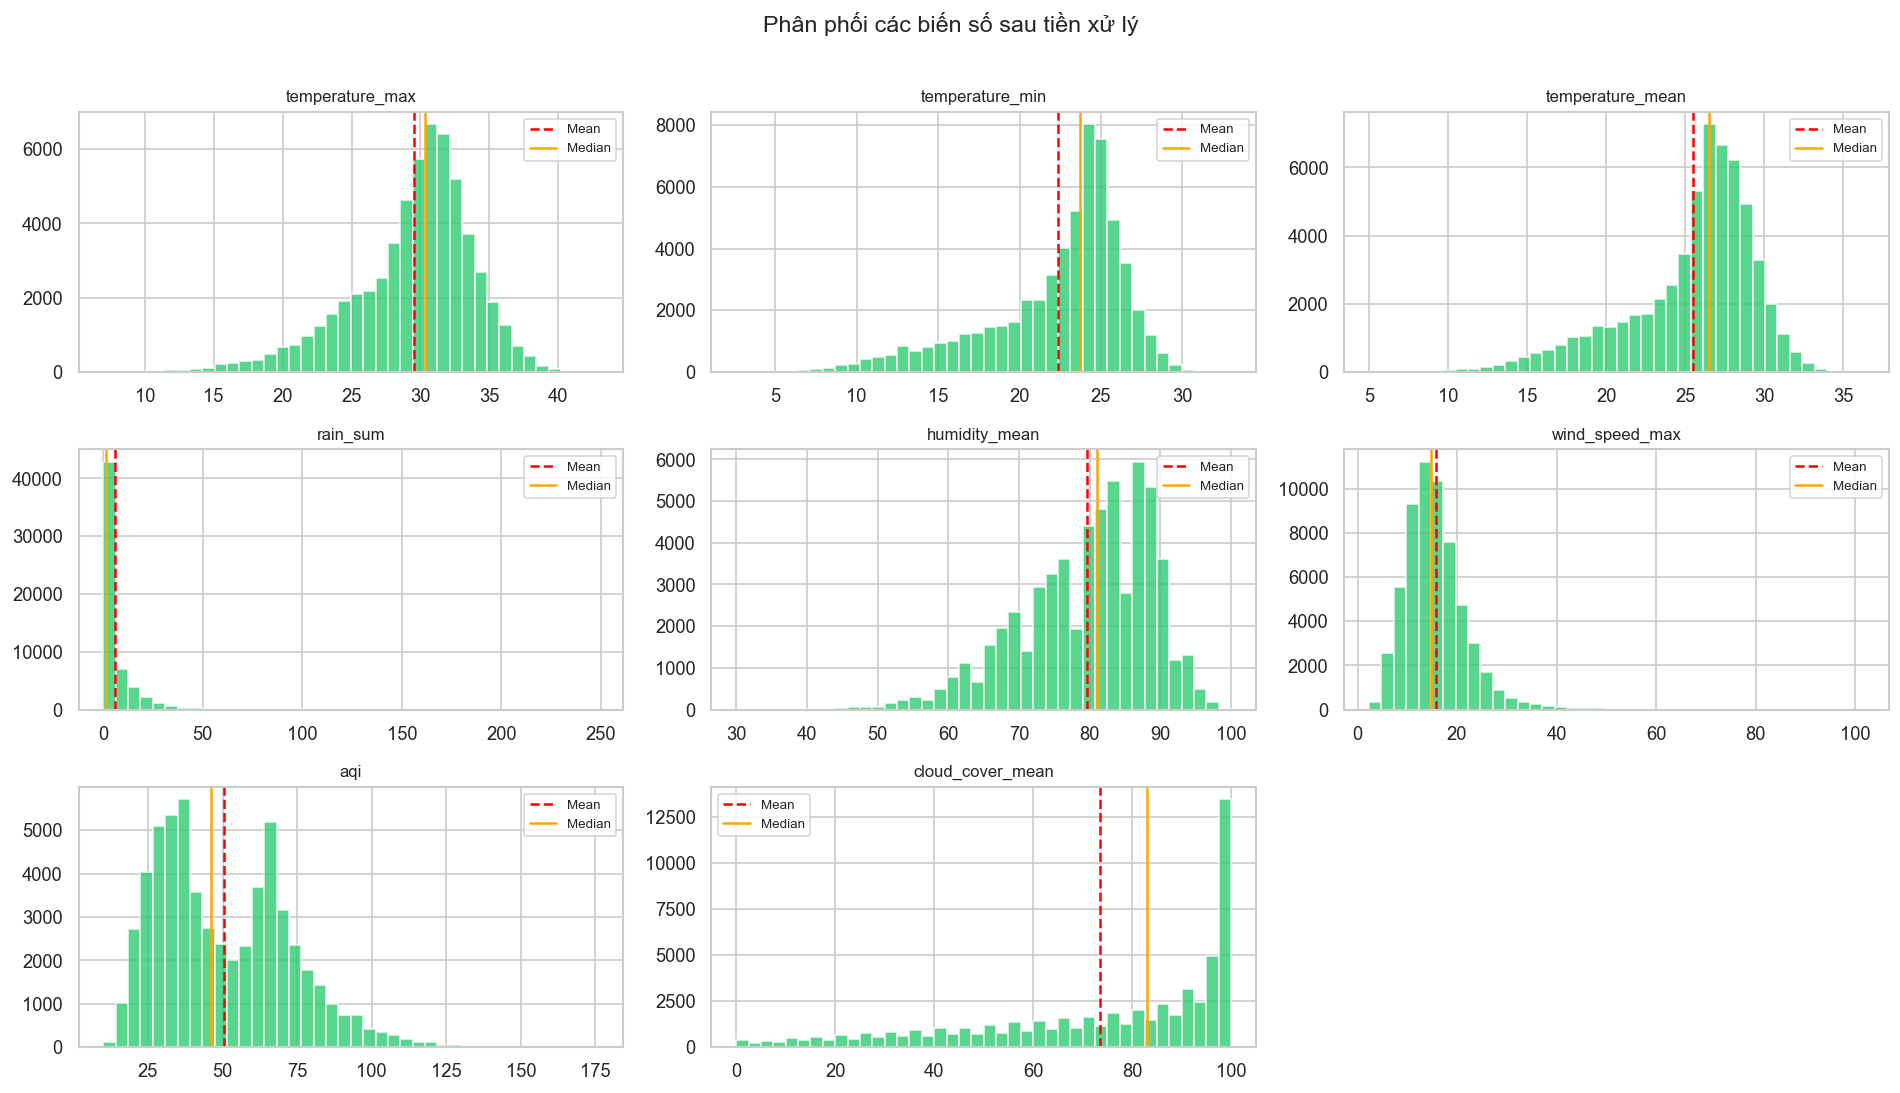

In [38]:
# --- Phân phối sau xử lý ---
plot_cols = [c for c in analysis_cols if c in df_clean.columns]
n_cols = 3
n_rows = int(np.ceil(len(plot_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    axes[i].hist(df_clean[col].dropna(), bins=40, color='#2ecc71', edgecolor='white', alpha=0.8)
    axes[i].axvline(df_clean[col].mean(),   color='red',    linestyle='--', lw=1.5, label='Mean')
    axes[i].axvline(df_clean[col].median(), color='orange', linestyle='-',  lw=1.5, label='Median')
    axes[i].set_title(col, fontsize=10)
    axes[i].legend(fontsize=8)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Phân phối các biến số sau tiền xử lý', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 6. Lưu Kết Quả

In [39]:
import os

OUTPUT_DIR  = '../backend/data/'
OUTPUT_FILE = os.path.join(OUTPUT_DIR, 'datasetall_cleaned.csv')

# Lưu dữ liệu đã xử lý
df_clean.to_csv(OUTPUT_FILE, index=False, encoding='utf-8-sig')

size_mb = os.path.getsize(OUTPUT_FILE) / 1024 / 1024
print(f'Đã lưu dữ liệu sạch tại: {OUTPUT_FILE}')
print(f'   Kích thước: {df_clean.shape[0]:,} dòng x {df_clean.shape[1]} cột')
print(f'   Dung lượng file: {size_mb:.2f} MB')
print(f'   Danh sách cột: {df_clean.columns.tolist()}')

Đã lưu dữ liệu sạch tại: ../backend/data/datasetall_cleaned.csv
   Kích thước: 58,835 dòng x 14 cột
   Dung lượng file: 4.87 MB
   Danh sách cột: ['date', 'city_id', 'province', 'country', 'latitude', 'longitude', 'temperature_max', 'temperature_min', 'temperature_mean', 'rain_sum', 'humidity_mean', 'wind_speed_max', 'aqi', 'cloud_cover_mean']


---
## Tóm Tắt Pipeline Tiền Xử Lý

| Bước | Thao tác | Kết quả |
|------|----------|---------|
| 1 | Đọc dữ liệu | `datasetall.csv` với `parse_dates=['date']` |
| 2 | Kiểm tra chất lượng | Đếm trùng lặp, missing, invalid, ngoại lai (IQR & Z-score) |
| 3 | Đánh giá & Quyết định | Trình bày các quyết định xử lý dữ liệu (giữ nguyên ngoại lai) |
| 4.1 | Xóa trùng | `drop_duplicates()` hoàn toàn & theo cặp khóa `(date, city_id)` |
| 4.2 | Xử lý không hợp lệ | Đưa giá trị ngoài phạm vi lý thuyết -> `NaN`, sửa logic nhiệt độ |
| 4.3 | Điền giá trị thiếu | `rain_sum` -> 0; ≤ 30% thiếu -> median theo tỉnh; > 30% -> median toàn cục |
| 4.4 | Xử lý ngoại lai | Giữ nguyên toàn bộ (hiện tượng cực đoan tự nhiên) |
| 4.5 | Thêm đặc trưng | year, month, day, quarter, dayofweek, season, aqi_category |
| 5 | Kiểm tra sau xử lý | Bảng so sánh trước/sau & histogram phân phối |
| 6 | Lưu kết quả | `datasetall_cleaned.csv` (UTF-8 BOM) |